# ETL walkthrough: from the downloaded files to the database

This notebook runs the data pipeline in `etl/` and shows what happens at every step: each stage is explained, run, and
its result displayed.

**What the pipeline does.** `download_data.py` has already saved each dataset under `raw/`. For each dataset the ETL
(1) checks the file against its checksum, (2) unzips it, (3) cleans it into a consistent shape, (4) checks the result,
and (5) optionally loads it into PostGIS as schema `vibrancy`. It only writes `staging/` and that schema, never any other table in the database.

**Before you start:** run `python download_data.py` (see its docstring; in Docker, the command is in `etl/README.md`).
A source that hasn't been downloaded is reported as `NOT RUN`, and the others carry on.

**How to run this notebook**

- **In VS Code:** choose a kernel that has the libraries: Python 3.11 with `etl/requirements.txt` installed (for
  example a conda environment called `vibrancy`). Then run the cells from the top.
- **In Docker, with nothing to install** (runs every cell and saves the result with its outputs in `output/`):

  ```bash
  docker compose run --rm --no-deps --user "$(id -u):$(id -g)" -e HOME=/tmp --entrypoint jupyter etl \
      nbconvert --to notebook --execute etl_walkthrough.ipynb --output-dir output \
      --output etl_walkthrough.executed.ipynb --ExecutePreprocessor.kernel_name=python3 --ExecutePreprocessor.timeout=-1
  ```

**What it costs.** The pipeline reads about 750 MB of downloads and unzips them to about 2.4 GB, which takes a few
minutes. To try it on a few small sources first, set `SOURCES` in the next cell.

## 0. Settings

Everything you might want to change is in the next cell.

| Setting | Meaning |
|---|---|
| `SOURCES` | Which sources to run. `None` is all of them. Or a list such as `["abs_population", "hospitals"]`. |
| `LOAD_TO` | `None`: files only, nothing goes into a database (the safe default). `"pgadmin"`: your PostgreSQL on port 5432 (the one pgAdmin shows), using `Credentials.json`, database `postgres`. `"compose"`: the database docker compose starts (only works inside Docker). |
| `RESET_FILES` | `True` deletes `raw/` and `staging/` in the last cell. It never touches any database. |

In [ ]:
import os

# Which sources to run: None = every source, or a list such as ["abs_population", "hospitals"].
# The environment variable ETL_SOURCES="abs_population hospitals" does the same.
SOURCES = os.environ.get("ETL_SOURCES", "").split() or None

LOAD_TO = None         # None = files only;  "pgadmin" = your PostgreSQL on port 5432;  "compose" = docker compose's database
RESET_FILES = False    # True = delete raw/ and staging/ in the last cell (never a database)

## 1. Where this is running

In [2]:
import inspect, json, platform, shutil, sys
from pathlib import Path

import pandas as pd
from IPython.display import Markdown, display

ROOT = Path.cwd()
if not (ROOT / "etl").is_dir():
    raise SystemExit("Open this notebook from the project folder (the one that contains etl/).")
sys.path.insert(0, str(ROOT))
IN_DOCKER = Path("/.dockerenv").exists()

from etl import cli, core, load, quality, schemas, stage
from etl.sources import BY_ID, SOURCES as REGISTRY, TABLES
from etl.sources import abs as abs_sources

pd.set_option("display.width", 170)
pd.set_option("display.max_colwidth", 90)

def show(obj):
    """Display the source code of a function, so you can read exactly what runs."""
    display(Markdown("```python\n" + inspect.getsource(obj) + "\n```"))

info = {"Python": platform.python_version(), "Inside Docker": IN_DOCKER, "Project folder": str(ROOT),
        "pandas": pd.__version__}
try:
    import geopandas, pandera
    info.update(geopandas=geopandas.__version__, pandera=pandera.__version__)
except ImportError as e:
    info["MISSING LIBRARY"] = str(e)
display(pd.Series(info, name="value").to_frame())

,value
Python,3.11.16
Inside Docker,False
Project folder,/home/juanvu/DATA2001 Assignments
pandas,2.2.3
geopandas,1.0.1
pandera,0.32.1


## 2. How the Docker commands map to this code

The commands in `etl/README.md` all end up running the same Python package, `etl/`. Docker's only job is to give it
the right Python and libraries. **Your code is not copied into the Docker image**: `docker-compose.yml` mounts your
project folder into the container at `/work`, so the files that run are the ones you see and edit.

| You type | What happens | Where the code is |
|---|---|---|
| `docker compose build etl` | Builds an image: Python 3.11 plus the exact library versions in `requirements.lock`. Needed once (and when `requirements.lock` changes). | `Dockerfile`, `requirements.lock` |
| `docker compose run --rm etl` | Starts the database container `db`, then a container from that image with your project mounted at `/work`, and runs `bash scripts/etl.sh run`. `--rm` deletes the container afterwards; your files stay. | `docker-compose.yml` (service `etl`), `scripts/etl.sh` |
| *(inside the container)* `python -m etl run` | Python runs the package `etl`; its entry point reads the sub-command and calls `cmd_run`. | `etl/__main__.py`, `etl/cli.py` |
| `... etl run --credentials Credentials.json --db-host host.docker.internal --db-name postgres` | The same run, but loading into your PostgreSQL on port 5432. `host.docker.internal` is how a container reaches your computer. | `load.connection_settings` in `etl/load.py` |
| `... --entrypoint python etl download_data.py` | Downloads the sources into `raw/` and records them in `raw/manifest.json`. It is not part of the `etl/` package. | `download_data.py` |
| `... --entrypoint python etl -m pytest tests -q` | Runs the tests. | `tests/` |
| **this notebook** | Calls the same functions directly from Python. | `cli.cmd_run` and the modules below |

**What `cmd_run` does, for each source in order** (`etl/cli.py`):

1. `Snapshot.from_record(...)`: look the source up in `raw/manifest.json` (written by `download_data.py`) and check that
   each file is there and matches its checksum (`etl/core.py`). It returns a `Snapshot`: the files, their checksums and the
   release. A source that isn't downloaded yet is reported as `NOT RUN`.
2. `src.parse(snap)`: if the download is a zip, unzip it first (`snap.unzip()`, `extract_zip`), then read the files and
   return cleaned tables as pandas or GeoPandas frames. This is the code in `etl/sources/`.
3. `quality.assess(...)`: run the source's own checks (`src.check`) and the pandera schema for each table
   (`schemas.validate_table`). A FAIL stops that source here, so bad data is never written.
4. `stage.write_staged(...)` saves each table into `staging/`, and the manifest is updated with what
   was read (`raw/manifest.json`).
5. After all the sources: `load.load(...)` writes the tables into PostGIS (schema `vibrancy`), adds indexes and comments, and
   fills `vibrancy.etl_manifest` and `vibrancy.data_quality_results`.
6. It writes `staging/data_quality_report.csv` and `staging/run_report.json`, prints a summary, and returns 0 if
   everything worked.

**The files in `etl/`, and what each one does**

| File | What it holds |
|---|---|
| `cli.py` | The commands `run` and `list`, and `cmd_run`, the loop above. |
| `core.py` | Paths and constants; the `Manifest`; `Snapshot` (a source's downloaded files); `Source` (parse and check bundled together); `Ctx` (the run's manifest and quality records); `extract_zip`; small helpers such as `to_int`. |
| `stage.py` | Writes and reads the cleaned tables in `staging/` (GeoPackage for spatial tables, CSV for the rest). |
| `sources/abs.py` | ABS: SA2 boundaries, businesses, income, population, mesh block dwellings. |
| `sources/aec.py` | Australian Electoral Commission polling places. |
| `sources/nsw.py` | NSW school catchments and hospitals. |
| `sources/tfnsw.py` | Transport for NSW GTFS stops and traffic lights. |
| `sources/osm.py` | OpenStreetMap: amenities, crossings, walkable roads, daily-living shops. |
| `sources/cityofsydney.py` | City of Sydney trees, stairs and mobility parking. |
| `quality.py` | `QualityRecord` (PASS, WARNING or FAIL) and `assess`, which runs both layers of checks. |
| `schemas.py` | The pandera schema for each table: columns, types, allowed values, ranges. |
| `load.py` | Chooses the database and loads the tables, indexes, comments and the manifest into schema `vibrancy`. |

The next sections run these one at a time.

## 3. The sources

Each source is registered in `etl/sources/__init__.py`, in an order that matters (the SA2 boundaries come first because
other checks use them).

In [3]:
registry = pd.DataFrame([{"source": s.id, "tables it makes": ", ".join(s.outputs), "what it is": s.title,
                          "licence": s.licence, "publisher": s.attribution} for s in REGISTRY])
display(registry)

,source,tables it makes,what it is,licence,publisher
0,asgs_sa2,sa2_boundaries,"SA2 boundaries (ASGS Edition 3, 2021)",CC BY 4.0,Australian Bureau of Statistics
1,abs_business,businesses,Counts of Australian Businesses (SA2 by industry by turnover),CC BY 4.0,Australian Bureau of Statistics
2,abs_income,income,"Personal Income in Australia (SA2, total income)",CC BY 4.0,Australian Bureau of Statistics
3,abs_population,population,"Regional population by age and sex (SA2, persons)",CC BY 4.0,Australian Bureau of Statistics
4,abs_mesh_blocks,mesh_blocks,"Census 2021 mesh block counts (dwellings, persons) with SA1 and SA2",CC BY 4.0,Australian Bureau of Statistics
5,catchments,schools,NSW school intake zones (catchment areas),CC BY (Data.NSW),NSW Department of Education
6,hospitals,hospitals,NSW Features of Interest: Health Facilities (hospitals),not verified (NSW Spatial Services),NSW Spatial Services
7,polling_places,polling_places,AEC federal election polling places,not verified (AEC),Australian Electoral Commission
8,gtfs_stops,stops,TfNSW Timetables Complete GTFS (stops.txt),CC BY (TfNSW Open Data),Transport for NSW
9,traffic_lights,traffic_lights,TfNSW Traffic Lights Location,CC BY (Data.NSW),Transport for NSW


## 4. One source, step by step

Every source is a `Source` with two functions: **parse** (clean into tables) and **check** (validate). Downloading is
done beforehand by `download_data.py`. `cmd_run` reads the manifest, then calls parse and check in order. Here we do
the same by hand for one small source, the ABS population estimates. The code for its `parse` is:

In [4]:
show(abs_sources.parse_population)

```python
def parse_population(snap: Snapshot) -> dict:
    wb = load_workbook(snap.path(), read_only=True, data_only=True)
    return {"population": parse_population_ws(population_sheet(wb))}

```

It opens the workbook the manifest points at (`snap.path()`) and hands its worksheet to `parse_population_ws`.
**Step 1: read the manifest.** This looks up the file `download_data.py` saved and checks its checksum. It doesn't use the
network.

In [5]:
ctx = core.Ctx()                       # the run's context: the manifest and the quality records
DEMO = BY_ID["abs_population"]
record = ctx.manifest.get(DEMO.id)     # written by download_data.py
snap = core.Snapshot.from_record(DEMO.id, record)   # raises an error if the file is missing or changed

print("release:", snap.release)
print("from   :", snap.url)
display(pd.DataFrame(snap.files).T[["path", "bytes", "sha256", "last_modified"]])

release: 30 June 2025
from   : https://www.abs.gov.au/statistics/people/population/regional-population-age-and-sex/2025/32350DS0001_2025.xlsx


,path,bytes,sha256,last_modified
main,raw/abs_population/2026-09-25/32350DS0001_2025.xlsx,1260381,35b4aadda000e7830813a8450cee2aa817891069353805a31e58f6fd3a3f4f02,"Wed, 05 Aug 2026 04:50:26 GMT"


The `sha256` is a fingerprint of the file. It goes into the manifest so the ETL can prove it is using
exactly the file that was downloaded. **Step 2: parse.** The workbook has title rows above the data and one column per age band; the
parser finds the header row by its content, keeps the Greater Sydney rows, and renames the columns:

In [6]:
show(abs_sources.parse_population_ws)

```python
def parse_population_ws(ws, year: int | None = None) -> pd.DataFrame:
    """Greater Sydney SA2 populations by five-year age band. Workbooks with one row per SA2 and year
    (the 2001 to latest series) need `year`."""
    rows = list(ws.iter_rows(min_col=1, max_col=40, values_only=True))
    h = next((i for i, r in enumerate(rows) if "SA2 code" in r), None)
    if h is None:
        raise EtlError("population sheet: no 'SA2 code' header")
    head, ages = rows[h], rows[h - 1]
    c_code, c_name, c_gcc = head.index("SA2 code"), head.index("SA2 name"), head.index("GCCSA code")
    c_year = head.index("Year") if "Year" in head else None
    bands = {}
    for c in range(c_name + 1, len(ages)):
        key = _age_label(ages[c]) if ages[c] is not None else None
        if key:
            bands[key] = c
    missing = [a for a in AGE_COLS + ["total"] if a not in bands]
    if missing:
        raise EtlError(f"population sheet: age columns not found: {missing}")
    data = []
    for r in rows[h + 1:]:
        if r[c_gcc] != "1GSYD" or not is_sa2_code(r[c_code]):
            continue
        if c_year is not None and year is not None and to_int(r[c_year]) != year:
            continue
        data.append([int(str(r[c_code]).strip()), r[c_name]] + [to_int(r[bands[a]]) for a in AGE_COLS + ["total"]])
    df = pd.DataFrame(data, columns=POP_COLS)
    for col in POP_COLS[2:]:
        df[col] = df[col].astype("Int64")
    return df.sort_values("SA2_CODE21").reset_index(drop=True)

```

In [7]:
tables = DEMO.parse(snap)              # {table name: DataFrame}
for name, df in tables.items():
    print(name, "->", df.shape[0], "rows x", df.shape[1], "columns")
    display(df.head(4))

population -> 373 rows x 21 columns


,SA2_CODE21,sa2_name,0-4_people,5-9_people,10-14_people,15-19_people,20-24_people,25-29_people,30-34_people,35-39_people,...,45-49_people,50-54_people,55-59_people,60-64_people,65-69_people,70-74_people,75-79_people,80-84_people,85-and-over_people,total_people
0,102011028,Avoca Beach - Copacabana,381,516,580,627,503,188,165,396,...,586,589,560,527,495,396,294,160,134,7578
1,102011029,Box Head - MacMasters Beach,487,619,689,637,492,325,310,484,...,668,740,760,850,917,899,865,534,388,11289
2,102011030,Calga - Kulnura,214,211,238,225,289,240,192,224,...,223,364,421,402,359,302,222,134,114,4678
3,102011031,Erina - Green Point,668,847,924,917,748,463,444,743,...,871,867,858,911,926,904,1092,803,755,14644


**Step 3: check.** `quality.assess` runs the source's own checks (row count, every Greater Sydney SA2 present, plausible
totals) and the pandera schema for the table. Here is the code, then its result:

In [8]:
show(quality.assess)

```python
def assess(source, out: dict, ctx) -> list:
    """All quality records for one source's tables: its built-in checks, then a pandera check per table."""
    from . import schemas  # imported here so that this module stays light

    records = [record_from_issues(source.id, out, source.check(out, ctx))]
    records += [schemas.validate_table(name, frame) for name, frame in out.items()]
    return records

```

In [9]:
records = quality.assess(DEMO, tables, ctx)
display(quality.records_to_frame(records))

,dataset,status,rows,columns,missing_values,duplicate_keys,notes
0,abs_population,PASS,373,21,0,0,ok
1,pandera:population,PASS,373,21,0,0,schema validation passed


Two records: one from the source's own checks (`abs_population`) and one from the pandera schema
(`pandera:population`). Any FAIL would stop this source. **Step 4: stage and record.** The table is saved into
`staging/` and the manifest is updated:

In [10]:
for name, df in tables.items():
    print("wrote staging/" + stage.write_staged(name, df))
ctx.manifest.put(DEMO.id, snap.to_record())
ctx.manifest.save()
print("recorded in", core.MANIFEST_PATH.relative_to(ROOT))

wrote staging/population.csv
recorded in raw/manifest.json


## 5. The code that does the work

Four functions carry most of the weight. They are shown here so you can read them.

**Checking a file against the manifest** (`Snapshot.from_record`, `etl/core.py`). It rebuilds the source's record from
`raw/manifest.json` and refuses to go on if a file is missing (`NOT RUN`, with the command that downloads it) or its
SHA-256 no longer matches (the file changed since it was downloaded):

In [11]:
show(core.Snapshot.from_record)

```python
    @classmethod
    def from_record(cls, source_id: str, record: dict) -> "Snapshot":
        """Rebuild a snapshot from the manifest, checking every file is there and intact."""
        snap = cls(source_id, record["release"], record["url"], record["files"],
                   record.get("extra", {}), record["retrieved_at"])
        for name, f in snap.files.items():
            p = ROOT / f["path"]
            if not p.exists():
                raise NotDownloaded(f"{source_id}: {f['path']} is missing. Run  python download_data.py {source_id}")
            if sha256_file(p) != f["sha256"]:
                raise EtlError(f"{source_id}: {f['path']} does not match its recorded checksum")
        return snap

```

**Unzipping** (`extract_zip`, `etl/core.py`). Every zip a source delivers is unzipped into a folder next to it before
anything is read. The zip is kept (so its checksum can still be checked), an earlier extraction is reused, and a file
whose path would land outside the folder is refused:

In [12]:
show(core.extract_zip)

```python
def extract_zip(path: Path) -> Path:
    """Unzip `path` into a folder next to it named after it, and return that folder.

    raw/<source>/<date>/name.zip becomes raw/<source>/<date>/name/. Zips inside it are unzipped too, each
    into a folder beside it. An earlier extraction of the same zip is reused. A file in the zip that would
    land outside the folder (a path with "..") is refused. The zip itself is kept, so its checksum can
    still be checked.
    """
    dest = path.with_suffix("")
    stamp = f"{path.stat().st_size}:{int(path.stat().st_mtime)}"
    marker = dest / ".unzipped"
    if marker.exists() and marker.read_text() == stamp:
        return dest
    if dest.exists():
        shutil.rmtree(dest)
    dest.mkdir(parents=True)
    root = dest.resolve()
    with zipfile.ZipFile(path) as z:
        for member in z.infolist():
            target = (root / member.filename).resolve()
            if root != target and root not in target.parents:
                raise EtlError(f"{path.name}: refusing to unzip {member.filename!r}, which would land outside {dest.name}/")
        z.extractall(dest)
    for inner in sorted(dest.rglob("*.zip")):
        extract_zip(inner)
    marker.write_text(stamp)
    return dest

```

**The pandera contract for a table** (`schemas.validate_table`). It looks up the table's schema and validates it,
collecting all the problems at once. A table with no problems returns PASS:

In [13]:
show(schemas.validate_table)

```python
def validate_table(name: str, frame) -> QualityRecord:
    """Check one table against its schema and return a record named "pandera:<table>"."""
    rows, cols, missing, dupes = counts(name, frame)

    def record(status: str, notes: str) -> QualityRecord:
        return QualityRecord(f"pandera:{name}", status, rows, cols, missing, dupes, notes)

    if not pandera_available():
        return record("WARNING", "Pandera is not installed; only the built-in checks were used.")
    import pandera.pandas as pa

    schema = build_schemas().get(name)
    if schema is None:
        return record("WARNING", "no schema is defined for this table")
    try:
        schema.validate(frame, lazy=True)
    except pa.errors.SchemaErrors as exc:
        return record("FAIL", _describe(exc.failure_cases))
    except Exception as exc:  # a schema that can't run is a problem too, not a pass
        return record("FAIL", f"schema could not be applied: {type(exc).__name__}: {str(exc)[:120]}")
    return record("PASS", "schema validation passed")

```

**Choosing the database** (`load.connection_settings`, `etl/load.py`). By default it uses the settings docker compose
passes in; `--credentials`, `--db-host` and `--db-name` override them, which is how the data reaches your pgAdmin database:

In [14]:
show(load.connection_settings)

```python
def connection_settings(credentials_file: str | None = None, host: str | None = None,
                        database: str | None = None) -> dict:
    """Where to load. By default the same rules as the notebook: DB_* environment variables (what docker compose
    sets, for its own database), then Credentials.json. `credentials_file` says to use that file instead of the
    environment, and `host` and `database` override what it names (for example host.docker.internal to reach
    a PostgreSQL that runs on your own computer, from inside Docker)."""
    if credentials_file:
        with open(ROOT / credentials_file, encoding="utf-8") as f:
            c = json.load(f)
        c.setdefault("database", c["user"])
    elif os.environ.get("DB_PASSWORD"):
        c = {"host": os.environ.get("DB_HOST", "localhost"), "port": int(os.environ.get("DB_PORT", "5432")),
             "user": os.environ.get("DB_USER", "postgres"), "password": os.environ["DB_PASSWORD"],
             "database": os.environ.get("DB_NAME", os.environ.get("DB_USER", "postgres"))}
    else:
        path = os.environ.get("CREDENTIALS_FILE", str(ROOT / "Credentials.json"))
        with open(path, encoding="utf-8") as f:
            c = json.load(f)
        c.setdefault("database", c["user"])
    if host:
        c["host"] = host
    if database:
        c["database"] = database
    return c

```

And the loop that ties it together, `cmd_run`:

In [15]:
show(cli.cmd_run)

```python
def cmd_run(args) -> int:
    ctx = Ctx()
    # --only accepts source ids (abs_business) or the table names they produce (businesses)
    wanted = [BY_ID[w].id if w in BY_ID else TABLES[w].id if w in TABLES else w for w in (args.only or [])]
    unknown = [w for w in wanted if w not in BY_ID]
    if unknown:
        sys.exit(f"unknown source(s): {', '.join(unknown)}. Try: python -m etl list")
    wanted = wanted or [s.id for s in SOURCES]

    started_at = utc_now()
    report, tables, failed = {}, {}, []
    for src in (s for s in SOURCES if s.id in wanted):
        print(f"\n== {src.id}: {src.title}", flush=True)
        started = time.time()
        try:
            record = ctx.manifest.get(src.id)  # written by download_data.py
            if record is None:
                raise NotDownloaded(f"{src.id} is not downloaded yet. Run  python download_data.py {src.id}")
            snap = Snapshot.from_record(src.id, record)  # checks the files against their checksums
            out = src.parse(snap)
            records = quality.assess(src, out, ctx)
            ctx.quality += records
            for r in records:
                if r.status != "PASS":
                    for note in r.notes.split("; "):
                        print(f"  [{r.status}] {r.dataset}: {note}")
            failures = [r for r in records if r.status == "FAIL"]
            if failures:
                raise EtlError("failed its checks: " + "; ".join(f"{r.dataset}: {r.notes}" for r in failures))
            for name, frame in out.items():
                ctx.frames[name] = frame
                tables[name] = frame
                print(f"  {name}: {len(frame):,} rows -> staging/{write_staged(name, frame)}")
            ctx.manifest.put(src.id, snap.to_record())
            ctx.manifest.save()
            print(f"  release: {snap.release}")
            report[src.id] = {"status": "ok", "release": snap.release, "seconds": round(time.time() - started, 1),
                              "rows": {n: len(f) for n, f in out.items()},
                              "issues": [f"{r.dataset}: {r.notes}" for r in records if r.status != "PASS"]}
        except NotDownloaded as e:
            failed.append(src.id)
            print(f"  NOT RUN: {e}")
            report[src.id] = {"status": "not run", "reason": str(e)}
        except Exception as e:
            failed.append(src.id)
            print(f"  FAILED: {e}")
            report[src.id] = {"status": "failed", "reason": str(e)}

    if not args.no_db and tables:
        try:
            from . import load
            settings = load.connection_settings(args.credentials, args.db_host, args.db_name)
            print(f"\n== loading into PostGIS at {load.describe(settings)}")
            table_sources = {t: TABLES[t] for t in tables}
            bad = load.load(tables, table_sources, dict(ctx.manifest.data["sources"]), BY_ID,
                            quality=quality.records_to_frame(ctx.quality).assign(run_at=started_at),
                            settings=settings)
            failed += [f"load:{t}" for t, _ in bad]
        except Exception as e:
            failed.append("load")
            print(f"  FAILED: could not load into the database: {str(e).splitlines()[0]}")

    STAGING.mkdir(parents=True, exist_ok=True)
    if ctx.quality:
        quality.records_to_frame(ctx.quality).to_csv(STAGING / "data_quality_report.csv", index=False)
    (STAGING / "run_report.json").write_text(json.dumps(
        {"finished_at": utc_now(), "sources": report}, indent=2), encoding="utf-8")
    print("\n== summary")
    for sid, r in report.items():
        print(f"  {sid:<16} {r['status']:<8} {r.get('release', r.get('reason', ''))}")
    if failed:
        print(f"\n{len(failed)} problem(s): {', '.join(failed)}")
        return 1
    print("\nAll sources loaded.")
    return 0

```

## 6. Run the whole pipeline

This is the equivalent of `docker compose run --rm etl`. It reads every source in `SOURCES` (all of them by default) from `raw/`,
prints the same log, and returns 0 if everything worked. First, turn `LOAD_TO` into the options the command takes:

In [16]:
import argparse

if LOAD_TO == "pgadmin":      # the PostgreSQL that pgAdmin shows, on port 5432 (database "postgres", not the "localhost" in Credentials.json)
    db = {"credentials": "Credentials.json", "db_host": "host.docker.internal" if IN_DOCKER else "localhost", "db_name": "postgres"}
else:                          # None (files only) or "compose" (the settings docker compose passes in)
    db = {"credentials": None, "db_host": None, "db_name": None}

args = argparse.Namespace(only=SOURCES, no_db=LOAD_TO is None, **db)
print("sources:", SOURCES or "all", "| load to:", LOAD_TO or "files only")

sources: all | load to: files only


In [17]:
exit_code = cli.cmd_run(args)
print("\nexit code:", exit_code, "(0 means every source was loaded)")


== asgs_sa2: SA2 boundaries (ASGS Edition 3, 2021)
  sa2_boundaries: 373 rows -> staging/sa2_boundaries.gpkg
  release: ASGS Edition 3 (2021)

== abs_business: Counts of Australian Businesses (SA2 by industry by turnover)
  businesses: 12,217 rows -> staging/businesses.csv
  release: June 2025

== abs_income: Personal Income in Australia (SA2, total income)
  [WARNING] abs_income: 5 SA2s have a missing value (np)
  income: 642 rows -> staging/income.csv
  release: 2022-23

== abs_population: Regional population by age and sex (SA2, persons)
  population: 373 rows -> staging/population.csv
  release: 30 June 2025

== abs_mesh_blocks: Census 2021 mesh block counts (dwellings, persons) with SA1 and SA2
  mesh_blocks: 60,881 rows -> staging/mesh_blocks.csv
  release: 2021 Census counts (released 28 June 2022)

== catchments: NSW school intake zones (catchment areas)
  schools: 2,114 rows -> staging/schools.gpkg
  release: enrolment year 2026

== hospitals: NSW Features of Interest: Health

## 7. What was produced

**`raw/`** holds each download exactly as it arrived, in a dated folder per source, and, next to every zip, the folder it
was unzipped into:

In [18]:
rows = []
for src_dir in sorted(core.RAW.glob("*")):
    if not src_dir.is_dir():
        continue
    for day in sorted(p for p in src_dir.iterdir() if p.is_dir()):
        for item in sorted(day.iterdir()):
            if item.name.endswith(".part"):
                continue
            size = sum(x.stat().st_size for x in item.rglob("*") if x.is_file()) if item.is_dir() else item.stat().st_size
            rows.append({"source": src_dir.name, "date": day.name, "item": item.name + ("/" if item.is_dir() else ""),
                         "MB": round(size / 1e6, 1), "kind": "unzipped folder" if item.is_dir() else "download"})
raw_files = pd.DataFrame(rows)
display(raw_files if len(raw_files) else "raw/ is empty")

,source,date,item,MB,kind
0,abs_business,2026-09-25,8165DC09.xlsx,8.3,download
1,abs_income,2026-09-25,personal_income_table1.xlsx,0.8,download
2,abs_mesh_blocks,2026-09-25,MB_2021_AUST.xlsx,35.3,download
3,abs_mesh_blocks,2026-09-25,mesh_block_counts_2021.xlsx,15.1,download
4,abs_population,2026-09-25,32350DS0001_2025.xlsx,1.3,download
5,asgs_sa2,2026-09-25,SA2_2021_AUST_SHP_GDA2020/,72.1,unzipped folder
6,asgs_sa2,2026-09-25,SA2_2021_AUST_SHP_GDA2020.zip,50.7,download
7,catchments,2026-09-25,catchments/,11.8,unzipped folder
8,catchments,2026-09-25,catchments.zip,8.4,download
9,cos_mobility_parking,2026-09-25,mobility_parking.geojson,0.2,download


**`raw/manifest.json`** records where each file came from, when, and its fingerprint:

In [19]:
if core.MANIFEST_PATH.exists():
    manifest = json.loads(core.MANIFEST_PATH.read_text())
    display(pd.DataFrame([{"source": k, "release": v["release"], "retrieved (UTC)": v["retrieved_at"],
                           "files": ", ".join(Path(f["path"]).name for f in v["files"].values()), "from": v["url"][:70]}
                          for k, v in sorted(manifest["sources"].items())]))

,source,release,retrieved (UTC),files,from
0,abs_business,June 2025,2026-09-25T14:47:48Z,8165DC09.xlsx,https://www.abs.gov.au/statistics/economy/business-indicators/counts-a
1,abs_income,2022-23,2026-09-25T14:47:51Z,personal_income_table1.xlsx,https://www.abs.gov.au/statistics/labour/earnings-and-working-conditio
2,abs_mesh_blocks,2021 Census counts (released 28 June 2022),2026-09-25T14:47:55Z,"MB_2021_AUST.xlsx, mesh_block_counts_2021.xlsx",https://www.abs.gov.au/census/guide-census-data/mesh-block-counts/2021
3,abs_population,30 June 2025,2026-09-25T14:47:53Z,32350DS0001_2025.xlsx,https://www.abs.gov.au/statistics/people/population/regional-populatio
4,asgs_sa2,ASGS Edition 3 (2021),2026-09-25T14:47:44Z,SA2_2021_AUST_SHP_GDA2020.zip,https://www.abs.gov.au/statistics/standards/australian-statistical-geo
5,catchments,enrolment year 2026,2026-09-25T14:48:36Z,catchments.zip,https://data.nsw.gov.au/data/dataset/8b1e8161-7252-43d9-81ed-6311569cb
6,cos_mobility_parking,"live service, retrieved 2026-09-25",2026-09-25T16:05:06Z,mobility_parking.geojson,https://services1.arcgis.com/cNVyNtjGVZybOQWZ/arcgis/rest/services/Mob
7,cos_stairs,"live service, retrieved 2026-09-25",2026-09-25T16:05:01Z,stairs.geojson,https://services1.arcgis.com/cNVyNtjGVZybOQWZ/arcgis/rest/services/Sta
8,cos_trees,"live service, retrieved 2026-09-25",2026-09-25T16:05:13Z,trees.geojson,https://services1.arcgis.com/cNVyNtjGVZybOQWZ/arcgis/rest/services/Tre
9,cos_walking_counts,City of Sydney walking count sites and survey averages,2026-09-26T04:42:52Z,walking_count_sites.geojson,https://services1.arcgis.com/cNVyNtjGVZybOQWZ/arcgis/rest/services/Wal


**`staging/`** holds the cleaned tables: `.gpkg` files for tables with locations, `.csv` for the rest:

In [20]:
rows = []
for src in REGISTRY:
    for table in src.outputs:
        df = stage.read_staged(table)
        if df is None:
            continue
        f = next(core.STAGING.glob(table + ".*"))
        rows.append({"table": table, "rows": len(df), "columns": df.shape[1], "file": f.name,
                     "MB": round(f.stat().st_size / 1e6, 1), "from source": src.id})
staged = pd.DataFrame(rows)
display(staged if len(staged) else "staging/ is empty")

,table,rows,columns,file,MB,from source
0,sa2_boundaries,373,17,sa2_boundaries.gpkg,6.1,asgs_sa2
1,businesses,12217,11,businesses.csv,0.9,abs_business
2,income,642,6,income.csv,0.0,abs_income
3,population,373,21,population.csv,0.0,abs_population
4,mesh_blocks,60881,7,mesh_blocks.csv,3.6,abs_mesh_blocks
5,schools,2114,4,schools.gpkg,12.9,catchments
6,hospitals,306,6,hospitals.gpkg,0.1,hospitals
7,polling_places,3028,13,polling_places.gpkg,0.6,polling_places
8,stops,171090,8,stops.gpkg,24.8,gtfs_stops
9,traffic_lights,4582,12,traffic_lights.gpkg,0.9,traffic_lights


**The quality report** has one line per check: the source's own checks and the pandera schema for each table. A WARNING is
something worth knowing (for example, a few traffic lights with typo coordinates that are kept with an empty location);
a FAIL would have stopped that source.

In [21]:
report_path = core.STAGING / "data_quality_report.csv"
if report_path.exists():
    quality_report = pd.read_csv(report_path)
    colour = {"PASS": "#d4edda", "WARNING": "#fff3cd", "FAIL": "#f8d7da"}
    display(quality_report.style.map(lambda s: f"background-color: {colour.get(s, 'white')}", subset=["status"]))

,dataset,status,rows,columns,missing_values,duplicate_keys,notes
0,asgs_sa2,PASS,373,17,0,0,ok
1,pandera:sa2_boundaries,PASS,373,17,0,0,schema validation passed
2,abs_business,PASS,12217,11,0,0,ok
3,pandera:businesses,PASS,12217,11,0,0,schema validation passed
4,abs_income,WARNING,642,6,20,0,5 SA2s have a missing value (np)
5,pandera:income,PASS,642,6,20,0,schema validation passed
6,abs_population,PASS,373,21,0,0,ok
7,pandera:population,PASS,373,21,0,0,schema validation passed
8,abs_mesh_blocks,PASS,60881,7,0,0,ok
9,pandera:mesh_blocks,PASS,60881,7,0,0,schema validation passed


## 8. Look at the data

In [22]:
for table in ["sa2_boundaries", "businesses", "stops", "hospitals", "traffic_lights"]:
    df = stage.read_staged(table)
    if df is not None:
        print(f"{table}: {len(df):,} rows")
        display(df.drop(columns="geom", errors="ignore").head(3))

sa2_boundaries: 373 rows


,SA2_CODE21,SA2_NAME21,CHG_FLAG21,CHG_LBL21,SA3_CODE21,SA3_NAME21,SA4_CODE21,SA4_NAME21,GCC_CODE21,GCC_NAME21,STE_CODE21,STE_NAME21,AUS_CODE21,AUS_NAME21,AREASQKM21,LOCI_URI21
0,102011028,Avoca Beach - Copacabana,0,No change,10201,Gosford,102,Central Coast,1GSYD,Greater Sydney,1,New South Wales,AUS,Australia,6.4376,http://linked.data.gov.au/dataset/asgsed3/SA2/102011028
1,102011029,Box Head - MacMasters Beach,0,No change,10201,Gosford,102,Central Coast,1GSYD,Greater Sydney,1,New South Wales,AUS,Australia,32.0802,http://linked.data.gov.au/dataset/asgsed3/SA2/102011029
2,102011030,Calga - Kulnura,0,No change,10201,Gosford,102,Central Coast,1GSYD,Greater Sydney,1,New South Wales,AUS,Australia,767.9512,http://linked.data.gov.au/dataset/asgsed3/SA2/102011030


businesses: 12,217 rows


,industry_code,industry_name,SA2_CODE21,sa2_name,0_to_50k_businesses,50k_to_200k_businesses,200k_to_2m_businesses,2m_to_5m_businesses,5m_to_10m_businesses,10m_or_more_businesses,total_businesses
0,A,"Agriculture, Forestry and Fishing",101021007,Braidwood,106,107,52,0,0,0,267
1,B,Mining,101021007,Braidwood,0,0,3,0,0,0,3
2,C,Manufacturing,101021007,Braidwood,7,8,7,0,3,0,23


stops: 171,090 rows


,stop_id,stop_code,stop_name,location_type,parent_station,wheelchair_boarding,platform_code
0,2533211,2533211,"Kiama Station, Platform 1",0,253330,1.0,1
1,2533212,2533212,"Kiama Station, Platform 2",0,253330,1.0,2
2,253330,None,Kiama Station,1,None,0.0,None


hospitals: 306 rows


,topoid,generalname,alternativelabel,classsubtype,operationalstatus
0,500686808,CALVARY JOHN JAMES HOSPITAL,None,3,1
1,500693917,THE CANBERRA HOSPITAL,None,3,1
2,500939741,CONDOBOLIN HEALTH SERVICE,None,3,1


traffic_lights: 4,582 rows


,equipment_id,asset_type,street_1,street_2,street_3,suburb,date_install,rms_region,col10,col11,col12
0,1,Vehicle,MARKET ST,KENT ST,None,SYDNEY,1936-05-13,HARZ,None,None,None
1,2,Vehicle,BRIDGE RD,ROSS ST,None,FOREST LODGE,1937-07-19,HARZ,None,None,None
2,3,Vehicle,BRIDGE RD,GLEBE POINT RD,None,GLEBE,1937-08-09,HARZ,None,None,None


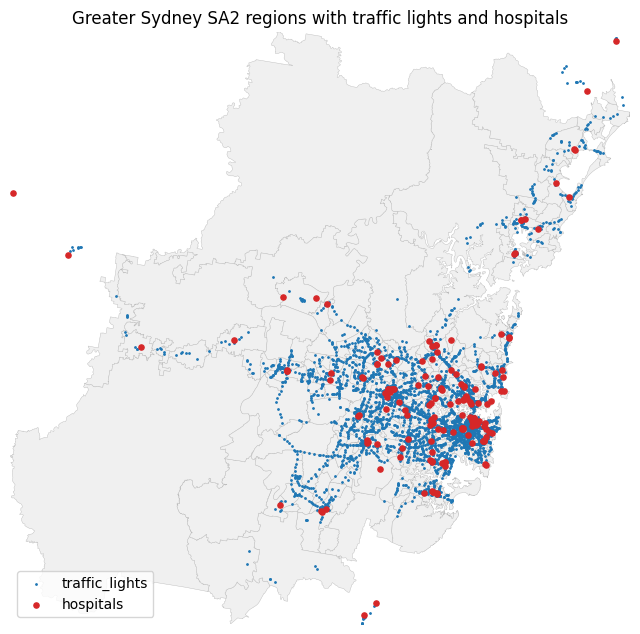

In [23]:
import matplotlib.pyplot as plt

sa2 = stage.read_staged("sa2_boundaries")
if sa2 is None:
    print("Run the asgs_sa2 source (and traffic_lights, hospitals) to draw the map.")
else:
    fig, ax = plt.subplots(figsize=(8, 8))
    sa2.plot(ax=ax, color="#f0f0f0", edgecolor="#bbbbbb", linewidth=0.3)
    for name, colour, size in (("traffic_lights", "#1f77b4", 1), ("hospitals", "#d62728", 14)):
        points = stage.read_staged(name)
        if points is not None:
            points[points.geometry.notna()].plot(ax=ax, color=colour, markersize=size, label=name)
    minx, miny, maxx, maxy = sa2.total_bounds
    ax.set_xlim(minx, maxx); ax.set_ylim(miny, maxy)
    ax.set_title("Greater Sydney SA2 regions with traffic lights and hospitals")
    ax.legend(loc="lower left"); ax.set_axis_off()
    plt.show()

## 9. In the database

If `LOAD_TO` was set, the tables are in schema `vibrancy`. This lists them from the database itself:

In [24]:
if LOAD_TO is None:
    print("LOAD_TO is None, so nothing was loaded. Set LOAD_TO = 'pgadmin' above and run section 6 again to load.")
else:
    from sqlalchemy import text

    if LOAD_TO == "pgadmin":
        settings = load.connection_settings(db["credentials"], db["db_host"], db["db_name"])
    else:
        settings = load.connection_settings()
    print("connected to", load.describe(settings))
    with load.engine(settings).connect() as conn:
        names = pd.read_sql(text("select table_name from information_schema.tables where table_schema = 'vibrancy' order by 1"),
                            conn)["table_name"].tolist()
        display(pd.DataFrame([{"table": n, "rows": conn.execute(text(f'select count(*) from vibrancy."{n}"')).scalar()} for n in names]))

LOAD_TO is None, so nothing was loaded. Set LOAD_TO = 'pgadmin' above and run section 6 again to load.


## 10. Start over

To wipe what the ETL made and run again, set `RESET_FILES = True` in section 0 and run the next cell. It deletes `raw/`
and `staging/` only: never a database. To remove the `vibrancy` tables from a database, run
`DROP SCHEMA IF EXISTS vibrancy CASCADE;` in pgAdmin's Query Tool.

In [25]:
if RESET_FILES:
    for folder in (core.RAW, core.STAGING):
        if folder.exists():
            shutil.rmtree(folder)
            print("deleted", folder.relative_to(ROOT))
else:
    print("RESET_FILES is False, so nothing was deleted.")

RESET_FILES is False, so nothing was deleted.
